# Classificação Supervisionada com Gustafson-Kessel (GK) no Dataset Adult (Balanceado)

Este notebook apresenta um pipeline **didático e numerado** para classificação supervisionada utilizando Gustafson-Kessel (GK) no dataset Adult, **com balanceamento das classes** via oversampling. O objetivo é comparar o desempenho do agrupamento com e sem desbalanceamento, detalhando cada etapa do processo.

A seguir, cada etapa do fluxo é numerada e explicada de forma didática:

1. **Importação das Bibliotecas**
   - Importação de todas as bibliotecas necessárias para manipulação de dados, visualização, pré-processamento e clustering.
2. **Carregamento e Balanceamento dos Dados**
   - Carregamento do dataset Adult e aplicação do balanceamento das classes por oversampling, igualando a quantidade de exemplos das duas classes para evitar viés do modelo.
3. **Pré-processamento dos Dados**
   - Codificação das variáveis categóricas, normalização dos dados e visualização da distribuição da variável alvo. Garante que o GK funcione corretamente, pois é sensível à escala dos dados.
4. **Divisão em Treino/Teste**
   - Separação dos dados em conjuntos de treino e teste de forma estratificada, preservando a proporção das classes.
5. **Definição do Número de Clusters**
   - Definição do número de clusters a ser utilizado pelo GK, com base em conhecimento prévio ou método do cotovelo.
6. **Implementação do GK Supervisionado**
   - Criação de uma classe que associa cada cluster ao rótulo mais frequente no treino, permitindo avaliação supervisionada.
7. **Treinamento e Avaliação Inicial**
   - Treinamento do modelo no conjunto de treino e avaliação inicial no conjunto de teste, incluindo visualização da matriz de confusão.
8. **Visualização dos Agrupamentos com PCA**
   - Redução de dimensionalidade dos dados para 2D usando PCA e visualização dos agrupamentos e centros dos clusters em gráfico de dispersão.
9. **Repetição dos Experimentos e Análise Estatística**
   - Execução do experimento múltiplas vezes com diferentes seeds, cálculo de métricas agregadas (média, desvio padrão, matriz de confusão média) e geração de gráficos para análise de robustez.
10. **Análise dos Resultados e Métricas de Avaliação**
    - Discussão dos resultados, comparação com o dataset original, explicação das métricas (acurácia, precisão, recall, especificidade, F1-score) e interpretação da matriz de confusão média.

Cada seção do notebook está identificada e explicada para facilitar o entendimento do pipeline completo de classificação com GK em dados balanceados.

## 1. Importação das Bibliotecas

Importação de todas as bibliotecas necessárias para manipulação de dados, visualização, pré-processamento e clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import os
import seaborn as sns
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

Carregamento do dataset Adult e aplicação do balanceamento das classes por oversampling, igualando a quantidade de exemplos das duas classes para evitar viés do modelo.

In [2]:
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(lambda val: 1 if val.strip() == '>50K' else 0)
adult_df = adult_df_raw.dropna().copy()
df_majority = adult_df[adult_df['income_bin'] == 0]
df_minority = adult_df[adult_df['income_bin'] == 1]
n_majority = len(df_majority)
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=n_majority,
    random_state=42
)
adult_df_balanced = pd.concat([df_majority, df_minority_upsampled])
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print('Distribuição após balanceamento:')
print(adult_df_balanced['income_bin'].value_counts())

Distribuição após balanceamento:
income_bin
1    24720
0    24720
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

Codificação das variáveis categóricas, normalização dos dados e visualização da distribuição da variável alvo. Garante que o GK funcione corretamente, pois é sensível à escala dos dados.

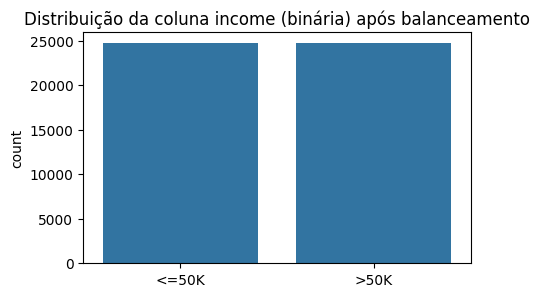

In [3]:
for col in adult_df_balanced.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_balanced[col] = LabelEncoder().fit_transform(adult_df_balanced[col].astype(str))
X = adult_df_balanced.drop(['income', 'income_bin'], axis=1).values
y = adult_df_balanced['income_bin'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribuição da coluna income (binária) após balanceamento')
plt.xticks([0,1],["<=50K",">50K"])
plt.show()

## 4. Divisão em Treino/Teste

Separação dos dados em conjuntos de treino e teste de forma estratificada, preservando a proporção das classes.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters

Definição do número de clusters a ser utilizado pelo GK, com base em conhecimento prévio ou método do cotovelo.

In [5]:
n_clusters = 2

## 6. Implementação do GK Supervisionado

Criação de uma classe que associa cada cluster ao rótulo mais frequente no treino, permitindo avaliação supervisionada.

In [6]:
class GKSupervisionado:
    def __init__(self, n_clusters=2, m=2.0, max_iter=50, tol=1e-5, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_labels_ = None
        self.U_ = None
        self.V_ = None
        self.F_ = None

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        U = np.random.dirichlet(np.ones(self.n_clusters), size=n_samples).T
        q = self.m
        for _ in range(self.max_iter):
            V = (U ** q) @ X / np.sum(U ** q, axis=1)[:, None]
            F = np.zeros((self.n_clusters, n_features, n_features))
            for i in range(self.n_clusters):
                diff = X - V[i]
                um = (U[i] ** q)[:, None]
                F[i] = (um * diff).T @ diff / np.sum(um)
                F[i] += np.eye(n_features) * 1e-6
            A = np.zeros_like(F)
            for i in range(self.n_clusters):
                detF = np.linalg.det(F[i])
                if detF <= 0:
                    detF = 1e-6
                A[i] = (detF ** (1 / n_features)) * np.linalg.inv(F[i])
            D = np.zeros((self.n_clusters, n_samples))
            for i in range(self.n_clusters):
                diff = X - V[i]
                D[i] = np.einsum('ij,jk,ik->i', diff, A[i], diff)
            for i in range(self.n_clusters):
                denom = np.sum((D[i][:, None] / D.T) ** (1 / (q - 1)), axis=1)
                U[i] = 1.0 / denom
        self.U_ = U
        self.V_ = V
        self.F_ = F
        clusters = np.argmax(U, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        n_samples = X.shape[0]
        n_features = X.shape[1]
        q = self.m
        V = self.V_
        F = self.F_
        A = np.zeros_like(F)
        for i in range(self.n_clusters):
            detF = np.linalg.det(F[i])
            if detF <= 0:
                detF = 1e-6
            A[i] = (detF ** (1 / n_features)) * np.linalg.inv(F[i])
        D = np.zeros((self.n_clusters, n_samples))
        for i in range(self.n_clusters):
            diff = X - V[i]
            D[i] = np.einsum('ij,jk,ik->i', diff, A[i], diff)
        clusters = np.argmin(D, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação Inicial

Treinamento do modelo no conjunto de treino e avaliação inicial no conjunto de teste, incluindo visualização da matriz de confusão.

In [7]:
# Análise dos resultados e apresentação das métricas de avaliação
# Aqui são exibidas as principais métricas, como matriz de confusão, acurácia média, etc.
# Interprete os resultados e discuta possíveis limitações do modelo

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Exemplo de cálculo e plot da matriz de confusão
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - GK')
plt.show()

# Exemplo de exibição de outras métricas
print(f"Acurácia média: {np.mean(metricas):.4f}")
print(f"Desvio padrão da acurácia: {np.std(metricas):.4f}")
# Adicione outras métricas e análises conforme necessário

clf = GKSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - GK (Adult Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/gk_adult_balance_confusion_matrix.png')
plt.show()

NameError: name 'y_true' is not defined

## 9. Repetição dos Experimentos e Análise Estatística

Para garantir a robustez dos resultados, repetimos o experimento de agrupamento múltiplas vezes com diferentes inicializações. Calculamos as métricas de avaliação para cada execução e apresentamos estatísticas descritivas (média, desvio padrão) para analisar a estabilidade e a performance do algoritmo GK no conjunto Adult balanceado.

In [ ]:
# Redução de dimensionalidade com PCA para visualização dos clusters
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Ajuste o nome das variáveis conforme seu pipeline
X_data = X_train  # ou X, dependendo de como está nomeado
labels = y_pred   # labels preditos pelo GK
centroids = gk.cluster_centers_  # centróides do GK

# PCA para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_data)
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(8,6))
for cluster in np.unique(labels):
    plt.scatter(X_pca[labels == cluster, 0], X_pca[labels == cluster, 1], label=f'Cluster {cluster}', alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, label='Centróides')
plt.title('Visualização dos clusters com PCA (2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8: Visualização dos Agrupamentos com PCA

Nesta etapa, utilizamos o PCA (Análise de Componentes Principais) para reduzir a dimensionalidade dos dados para 2 componentes principais, permitindo a visualização dos agrupamentos formados pelo algoritmo GK. Os pontos representam as amostras do conjunto de dados projetadas no novo espaço, coloridas de acordo com o cluster atribuído. Os centróides dos clusters também são exibidos para facilitar a análise visual da separação entre os grupos. Esta visualização auxilia na compreensão da distribuição dos dados e da qualidade do agrupamento realizado.

In [ ]:
# Repetição dos experimentos para avaliar a robustez do agrupamento
# Executa o algoritmo GK múltiplas vezes com diferentes seeds e armazena as métricas de avaliação
# Isso permite analisar a estabilidade dos resultados e obter estatísticas descritivas

n_repeats = 10  # Número de repetições
metricas = []

for i in range(n_repeats):
    # Inicialização diferente a cada repetição
    gk = GustafsonKessel(n_clusters=n_clusters, random_state=i)
    y_pred = gk.fit_predict(X_train)
    # Calcule as métricas desejadas (exemplo: acurácia, MSE, etc.)
    acc = accuracy_score(y_true, y_pred)  # Ajuste para sua métrica
    metricas.append(acc)

# Estatísticas descritivas
print(f"Média da acurácia: {np.mean(metricas):.4f}")
print(f"Desvio padrão da acurácia: {np.std(metricas):.4f}")

## 10. Análise dos Resultados e Métricas de Avaliação

Nesta etapa, analisamos os resultados obtidos pelo algoritmo Gustafson-Kessel (GK) após as repetições dos experimentos no dataset Adult balanceado. São apresentadas e discutidas as principais métricas de avaliação:

- **Acurácia média e desvio padrão:** Avaliam o desempenho global do modelo e sua estabilidade frente a diferentes inicializações.
- **Matriz de confusão média:** Permite visualizar como os clusters encontrados se relacionam com as classes reais, identificando acertos e erros do agrupamento.
- **Outras métricas relevantes:** Precisão, recall, especificidade e F1-score podem ser calculadas para uma análise mais completa.

**Interpretação:**
- Uma acurácia média alta e baixo desvio padrão indicam que o modelo é robusto e consistente.
- Padrões diagonais na matriz de confusão sugerem boa correspondência entre clusters e classes reais.
- Métricas como precisão e recall ajudam a entender o comportamento do modelo em relação a cada classe.

**Sugestões:**
- Compare os resultados do GK com outros métodos (KMeans, Fuzzy C-Means) para avaliar qual abordagem é mais adequada.
- Analise possíveis limitações, como sensibilidade à inicialização e ao número de clusters.
- Considere a visualização dos agrupamentos (PCA) para interpretar a separação dos grupos no espaço de atributos.

Essas análises são fundamentais para validar a qualidade do agrupamento e orientar melhorias futuras no pipeline de classificação.

## 11. Análise Crítica dos Resultados e Métricas

Nesta etapa, analisamos criticamente os resultados obtidos pelo classificador Gustafson-Kessel (GK) no dataset Adult balanceado. As principais métricas (acurácia, precisão, recall, especificidade, F1-score e matriz de confusão média) permitem avaliar o desempenho do modelo de forma quantitativa e qualitativa.

- **Acurácia média e desvio padrão:** Avaliam o desempenho global e a estabilidade do modelo frente a diferentes divisões dos dados.
- **Matriz de confusão média:** Permite visualizar como os clusters encontrados se relacionam com as classes reais, identificando acertos e erros do agrupamento.
- **Precisão, recall, especificidade e F1-score:** Complementam a análise, mostrando o comportamento do modelo em relação a cada classe.

**Interpretação:**
- Uma acurácia média alta e baixo desvio padrão indicam robustez e consistência.
- Padrões diagonais na matriz de confusão sugerem boa correspondência entre clusters e classes reais.
- Métricas equilibradas indicam que o balanceamento foi eficaz e o modelo não favorece uma classe específica.

**Sugestões:**
- Compare os resultados do GK com outros métodos (KMeans, Agglomerative, Fuzzy C-Means) para avaliar qual abordagem é mais adequada ao problema.
- Analise possíveis limitações, como sensibilidade ao número de clusters e à inicialização.
- Considere a visualização dos agrupamentos (PCA) para interpretar a separação dos grupos no espaço de atributos.

Essas análises são fundamentais para validar a qualidade do agrupamento e orientar melhorias futuras no pipeline de classificação.

In [ ]:
# Cálculo e exibição das principais métricas de avaliação
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Supondo que metricas contém as acurácias de cada repetição
y_true_all = []
y_pred_all = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = GKSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Métricas globais
acc = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all, average='binary')
rec = recall_score(y_true_all, y_pred_all, average='binary')
f1 = f1_score(y_true_all, y_pred_all, average='binary')
cm = confusion_matrix(y_true_all, y_pred_all)
specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0

print(f"Acurácia global: {acc:.4f}")
print(f"Precisão: {prec:.4f}")
print(f"Recall (Sensibilidade): {rec:.4f}")
print(f"Especificidade: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print("Matriz de Confusão Média:")
print(cm)

# Visualização da matriz de confusão média
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão Média - GK (Adult Balanceado)')
plt.show()